In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Features:", X.shape)
print("Classes:", np.unique(y))

Features: (569, 30)
Classes: [0 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = DecisionTreeClassifier(
    max_depth=4,   # keep tree small for interpretation
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



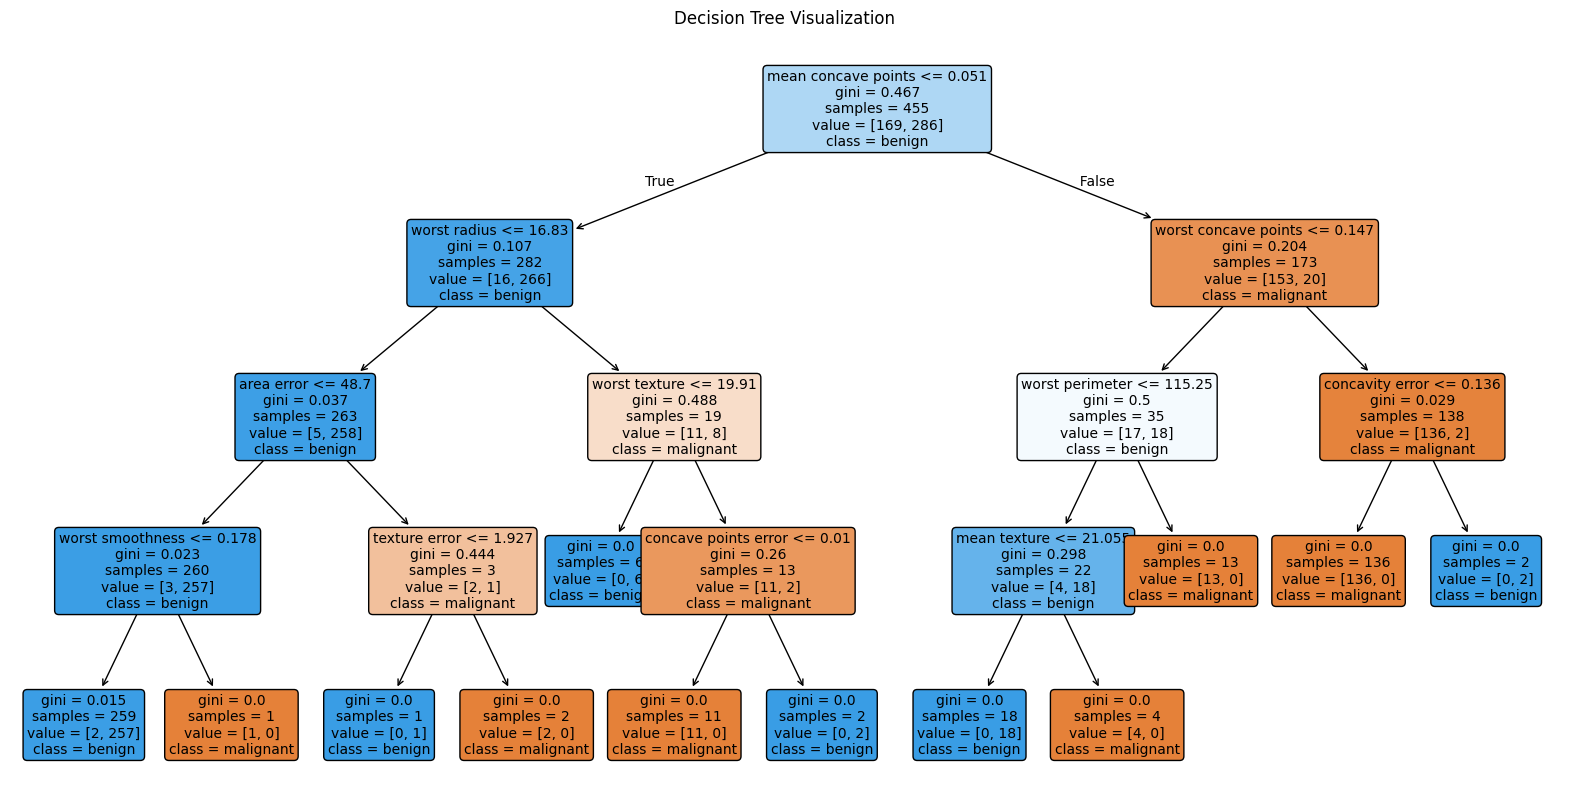

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df.head(10))

                 Feature  Importance
7    mean concave points    0.704583
27  worst concave points    0.066901
20          worst radius    0.053295
22       worst perimeter    0.052474
1           mean texture    0.031395
21         worst texture    0.028196
16       concavity error    0.018908
17  concave points error    0.016234
13            area error    0.012211
24      worst smoothness    0.009409


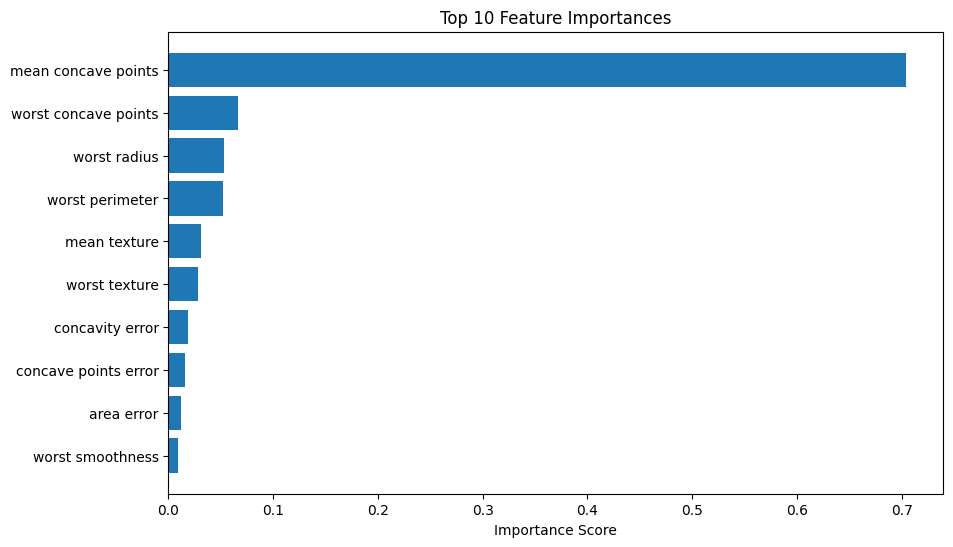

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'][:10],
    feature_importance_df['Importance'][:10]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.show()